# Practical Examples

Complete working examples you can run and modify.

## Example 1: Multi-Detector Scan

In [1]:
import sys
from pathlib import Path

parent_dir = Path.cwd().parent if 'jupyter_book_tutorial' in str(Path.cwd()) else Path.cwd()
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

from bluesky import RunEngine
from ophyd import Signal
from bluesky.plans import scan
from bluesky_config.devices import MockDetector
from bluesky_config.callbacks import DocumentLogger
from databroker import Broker

# Setup
RE = RunEngine({})
doc_logger = DocumentLogger(str(parent_dir / 'data' / 'documents'))
RE.subscribe(doc_logger)
db = Broker.named('temp')
RE.subscribe(db.v1.insert)

# Create devices
motor = Signal(name='motor', value=0)
det1 = MockDetector(name='det1', noise_level=0.1)
det2 = MockDetector(name='det2', noise_level=0.2)

# Scan with TWO detectors
uid = RE(scan([det1, det2], motor, 0, 10, 20))

# View results
run = db[-1]
table = run.table()
print(f"Columns: {list(table.columns)}")
table[['motor', 'det1_value', 'det2_value']].head()

📝 Logging documents to: 3ac7d3f6_documents.jsonl

   Saved stop document

Columns: ['time', 'det1_value', 'det2_value', 'motor']

,motor,det1_value,det2_value
seq_num,,,
1,0.000000,1.011198,1.148916
2,0.526316,1.053167,1.093682
3,1.052632,1.023185,0.988153
4,1.578947,1.064635,1.119544
5,2.105263,1.115847,1.144408


## Example 2: Batch Processing

In [2]:
# Run 3 scans with different parameters
batch_uids = []

for noise in [0.1, 0.3, 0.5]:
    det1.noise_level = noise
    uid = RE(scan([det1], motor, 0, 10, 15))
    batch_uids.append(uid[0])
    print(f"Run {len(batch_uids)}: {uid[0][:8]} (noise={noise})")

print(f"\n✓ Completed {len(batch_uids)} batch runs")

📝 Logging documents to: 4f3e3c2e_documents.jsonl

   Saved stop document

Run 1: 4f3e3c2e (noise=0.1)

📝 Logging documents to: 40886e12_documents.jsonl

   Saved stop document

Run 2: 40886e12 (noise=0.3)

📝 Logging documents to: efa59649_documents.jsonl

   Saved stop document

Run 3: efa59649 (noise=0.5)


✓ Completed 3 batch runs

### Compare Batch Results

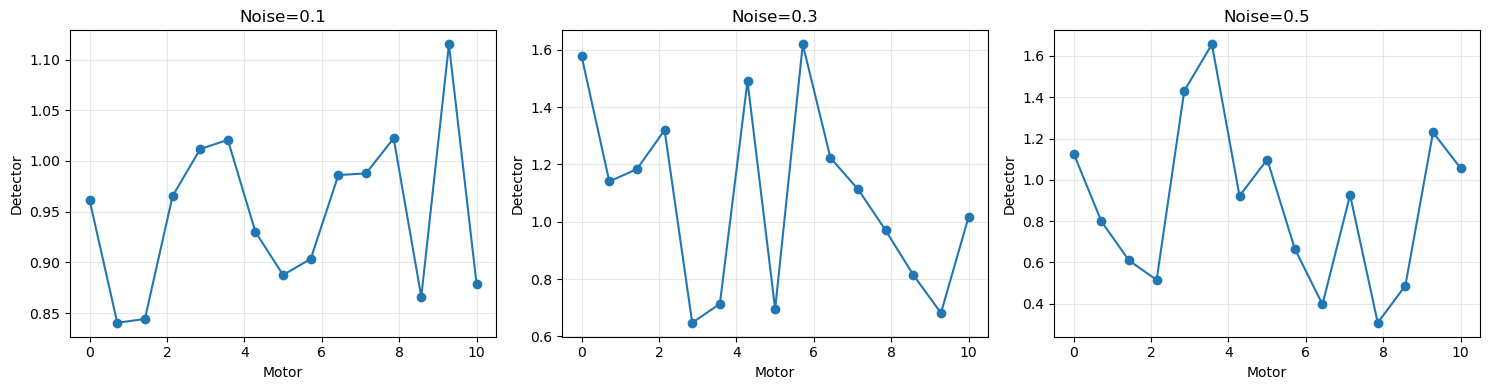

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, uid in enumerate(batch_uids):
    run = db[uid]
    table = run.table()
    axes[i].plot(table['motor'], table['det1_value'], 'o-')
    axes[i].set_title(f"Noise={[0.1, 0.3, 0.5][i]}")
    axes[i].set_xlabel('Motor')
    axes[i].set_ylabel('Detector')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Example 3: Real-Time Peak Detection

In [4]:
from bluesky_config.callbacks import PeakDetectorCallback

# Add peak detector callback
peak_detector = PeakDetectorCallback('det1_value', threshold=2.0)
RE.subscribe(peak_detector)

# Run scan
det1.noise_level = 0.4  # Higher noise for more peaks
uid = RE(scan([det1], motor, 0, 10, 30))

# Show detected peaks
print(f"\nDetected {len(peak_detector.peaks)} peaks:")
for motor_pos, det_val in peak_detector.peaks[:5]:  # Show first 5
    print(f"  Motor={motor_pos:.2f}, Detector={det_val:.3f}")

📝 Logging documents to: 312d7056_documents.jsonl


🔍 Peak Detector: Monitoring 'det1_value'

   Alert threshold: 2.0

   Position signal: 'motor' (auto-detected)

   Saved stop document


   📊 Peak Summary:

      Peak value: 1.8634

      Peak position (motor): 3.4483e+00

AttributeError: 'PeakDetectorCallback' object has no attribute 'peaks'

## Example 4: Export and Share

In [ ]:
from analysis.export import export_for_analysis

# Export in multiple formats
run = db[-1]
export_dir = str(parent_dir / 'data' / 'exports' / 'example4')

export_for_analysis(run, export_dir, formats=['csv', 'hdf5', 'json'])
print(f"✓ Data exported to: {export_dir}")
print("  - CSV for Excel/Python pandas")
print("  - HDF5 for efficient storage")
print("  - JSON for metadata")

## Try It Yourself

**Challenge 1**: Scan with 3 detectors simultaneously

**Challenge 2**: Run 10 batch scans with noise from 0.1 to 1.0

**Challenge 3**: Create a custom plot comparing all batch runs

## Next Steps

→ **Chapter 7: [Troubleshooting](07_troubleshooting.ipynb)**